# 🎓 Assignment 3
## ✅ Rename the filename with your roll number. E.g. if your roll number is `MT24003` then rename the file `MT24003_a3.ipynb` before submitting.
## ✅ Write code only in the sections marked with `# YOUR CODE HERE`. No, you can NOT write code anywhere else.
## ✅ Download and extract the `MLA3_DATA.zip` folder next to this file. If you extract it correctly, you will have a `MLA3_DATA` folder next to this file.
## ❌ Do not modify any other function or class definitions; doing so may lead to the autograder failing to judge your submission, resulting in a zero.
## ❌ Deleting or adding new cells may lead to the `autograder` failing to judge your submission, resulting in a zero. Even if a cell is empty, do NOT delete it.
## ❌ Do NOT install / import any other libraries. You should be able to solve all the questions using only the libraries imported below.


In [1]:
# =======================
# DO NOT MODIFY THIS CELL
# =======================

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
import scipy

# Base paths
PATH_TO_DATA_DIR = "./MLA3_DATA"
PATH_TO_TRAIN_DIR = os.path.join(PATH_TO_DATA_DIR, "TRAIN")
PATH_TO_TEST_DIR = os.path.join(PATH_TO_DATA_DIR, "TEST")

# Train and Test CSV paths
PATH_TO_TRAIN_FILE = os.path.join(PATH_TO_TRAIN_DIR, "train.csv")
PATH_TO_STUDENT_TEST_FILE = os.path.join(PATH_TO_TEST_DIR, "student_test.csv")
PATH_TO_HIDDEN_TEST_SAMPLE_FILE = os.path.join(PATH_TO_TEST_DIR, "hidden_test_sample.csv")


# `q0` EDA

* The dataset in this assignment mimics a real-world dataset and contains various artifacts, such as missing values, categorical features, and outliers.
* Your task is to train three models: Decision Tree, Gradient Boosting, and SVM. The trained models will be tested on both a visible test set and a hidden test set, which will not be accessible to you.
* To help you apply consistent preprocessing across the train, student test, and hidden test sets, we provide a very small sample of the hidden test data (3 rows). **This sample is only for sanity-checking your preprocessing code; your marks will be based on the performance of your notebook on the full hidden test dataset (~100 rows) when it is re-run after the submission deadline.**
* Additionally, the given hidden test sample does not contain the label column, so you will not be able to evaluate your model on it. Think of this dataset as the *live* data your model will experience after deployment in the wild.
* This assignment is designed to build your intuition for real-world data, highlight the importance of EDA and feature engineering, and illustrate concepts such as generalizability and overfitting.
* Given the peculiar nature of the dataset, you are strongly encouraged to do it for your own understanding.

### Grading:
* This question is not graded.

In [2]:
# YOUR CODE HERE

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, MinMaxScaler
from sklearn.feature_selection import chi2, SelectKBest
from sklearn.ensemble import RandomForestClassifier
import sklearn.tree
import sklearn.ensemble
import sklearn.svm
import numpy as np
import pandas as pd


# ------------------------------------------------------------------------------------------------------------
# Load the training data into a pandas DataFrame
df_train = pd.read_csv(PATH_TO_TRAIN_FILE)

# Display the first few rows of the dataframe
print("--- First 5 Rows ---")
display(df_train.head())

# Display a concise summary of the dataframe, including data types and non-null values
print("\n--- Dataframe Info ---")
df_train.info()

# Display summary statistics for numerical columns
print("\n--- Numerical Summary ---")
display(df_train.describe())

# Display summary statistics for categorical columns
print("\n--- Categorical Summary ---")
display(df_train.describe(include=['object']))

# Check for the number of missing values in each column
print("\n--- Missing Values ---")
print(df_train.isnull().sum())

# Check the distribution of the target variable 'class'
print("\n--- Target Variable Distribution ---")
print(df_train['class'].value_counts())

--- First 5 Rows ---


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,class
0,26.08,8.665,u,g,aa,v,1.415,t,f,0,f,g,160.0,150,1
1,28.92,0.375,u,g,c,v,0.290,f,f,0,f,g,220.0,140,0
2,20.83,0.500,y,p,e,dd,1.000,f,f,0,f,g,260.0,0,0
3,22.17,12.125,u,g,c,v,3.335,f,t,2,t,g,180.0,173,0
4,54.33,6.750,u,g,c,h,2.625,t,t,11,t,g,0.0,284,1



--- Dataframe Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      483 non-null    float64
 1   A2      510 non-null    float64
 2   A3      495 non-null    object 
 3   A4      495 non-null    object 
 4   A5      484 non-null    object 
 5   A6      484 non-null    object 
 6   A7      510 non-null    float64
 7   A8      510 non-null    object 
 8   A9      510 non-null    object 
 9   A10     510 non-null    int64  
 10  A11     495 non-null    object 
 11  A12     510 non-null    object 
 12  A13     497 non-null    float64
 13  A14     510 non-null    int64  
 14  class   510 non-null    int64  
dtypes: float64(4), int64(3), object(8)
memory usage: 59.9+ KB

--- Numerical Summary ---


,A1,A2,A7,A10,A13,A14,class
count,483.000000,510.000000,510.000000,510.000000,497.000000,510.000000,510.00000
mean,31.604534,4.742716,2.219608,2.545098,179.647887,894.617647,0.45098
std,11.685423,4.979507,3.377056,5.151242,161.890615,3437.711016,0.49808
min,15.170000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,22.920000,1.000000,0.250000,0.000000,70.000000,0.000000,0.00000
50%,28.500000,2.540000,1.000000,0.000000,160.000000,6.000000,0.00000
75%,38.210000,7.437500,2.585000,3.000000,268.000000,373.000000,1.00000
max,80.250000,28.000000,28.500000,67.000000,1160.000000,50000.000000,1.00000



--- Categorical Summary ---


,A3,A4,A5,A6,A8,A9,A11,A12
count,495,495,484,484,510,510,495,510
unique,3,3,14,9,2,2,2,3
top,u,g,c,v,t,f,f,g
freq,389,390,100,285,272,284,270,460



--- Missing Values ---
A1       27
A2        0
A3       15
A4       15
A5       26
A6       26
A7        0
A8        0
A9        0
A10       0
A11      15
A12       0
A13      13
A14       0
class     0
dtype: int64

--- Target Variable Distribution ---
class
0    280
1    230
Name: count, dtype: int64


# `q1` Data Loading, Preprocessing, and Feature Engineering

* You are free to perform any preprocessing and feature engineering you want.
* Populate the `Dataset` class with your preprocessing + feature engineering code.

### Grading:
* This question is not graded but will be used later in graded questions.

In [12]:
class Dataset:
    """
    CSV loader that returns X, y as numpy arrays for sklearn. Label column is 'class'.
    """

    def __init__(self, filepath: str, preprocessor: sklearn.compose.ColumnTransformer = None, do_fit: bool = True):
        """
        filepath: path to CSV with features + a label column named 'class'
        preprocessor: optional fitted sklearn ColumnTransformer (provide for test/hidden runs)
        do_fit: whether to fit the preprocessor on this data
        """
        self.filepath = filepath
        self.preprocessor = preprocessor
        self.features = None
        self.labels = None
        self._load_and_preprocess(do_fit)

    def _load_and_preprocess(self, do_fit: bool = True):
        """
        Load CSV, split on label 'class', apply (or fit+apply) preprocessor,
        and populate self.features, self.labels, self.feature_names, self.preprocessor.
        """
        # YOUR CODE HERE
        # --- FIX: Define BEST_FEATURES as a flat list of strings ---
        BEST_FEATURES = [
            # 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 
            # 'A10', 'A11', 'A12', 'A13', 'A14' 
            # 'A11', 'A1', 'A4', 'A9', 'A6', 'A7', 'A5', 'A8', 'A2', 'A14', 'A10', 'A13'   ----- 64,66,74
            # 'A1', 'A4', 'A9', 'A6', 'A7', 'A5', 'A14', 'A2', 'A8', 'A10', 'A13' ------ 68,64,68
            # 'A7', 'A14', 'A8', 'A10', 'A13'  ----- 68,70,75
            # 'A14', 'A10', 'A8', 'A7', 'A12' ----- 70,72,77
            # 'A12', 'A10', 'A6', 'A7', 'A8', 'A14', 'A13', 'A4'  ------- B
            # 'A2', 'A7', 'A14', 'A8', 'A13', 'A12', 'A4'   -------B
            'A2', 'A7', 'A14', 'A8', 'A13', 'A12', 'A4', 'A6'  
            # 'A3', 'A10', 'A14', 'A8', 'A13', 'A12', 'A4', 'A6'
        ]

        # ========== FOR _load_and_preprocess() ==========

        # Load the CSV file
        df = pd.read_csv(self.filepath)

        # Separate features and labels
        if 'class' in df.columns:
            self.labels = df['class'].to_numpy()
            features_df = df.drop('class', axis=1)
        else:
            self.labels = None
            features_df = df
            
        # SELECT ONLY THE BEST FEATURES
        features_df = features_df[BEST_FEATURES]

        # Identify column types
        numerical_features = features_df.select_dtypes(include=np.number).columns.tolist()
        categorical_features = features_df.select_dtypes(exclude=np.number).columns.tolist()

        if do_fit:
            numerical_transformer = Pipeline(steps=[
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ])

            categorical_transformer = Pipeline(steps=[
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
            ])

            self.preprocessor = ColumnTransformer(
                transformers=[
                    ('num', numerical_transformer, numerical_features),
                    ('cat', categorical_transformer, categorical_features)
                ]
            )
            
            self.features = self.preprocessor.fit_transform(features_df)
            
        else:
            if self.preprocessor is None:
                raise ValueError("Fitted preprocessor required")
            
            self.features = self.preprocessor.transform(features_df)

        self.feature_names = self.preprocessor.get_feature_names_out()

    def get_features_and_labels(self):
        """
        Return (X, y) where X is 2D numpy array and y is 1D numpy array.
        """
        return self.features, self.labels


In [13]:
# =======================
# DO NOT MODIFY THIS CELL
# =======================

train_ds = Dataset(PATH_TO_TRAIN_FILE, do_fit=True)
X_train, y_train = train_ds.get_features_and_labels()

test_ds = Dataset(
    PATH_TO_STUDENT_TEST_FILE,
    preprocessor=train_ds.preprocessor,
    do_fit=False
)
X_test, y_test = test_ds.get_features_and_labels()

hidden_ds = Dataset(
    PATH_TO_HIDDEN_TEST_SAMPLE_FILE,
    preprocessor=train_ds.preprocessor,
    do_fit=False
)
X_hidden, y_hidden = hidden_ds.get_features_and_labels()

print(f"[Train] X: {X_train.shape}, y: {y_train.shape}")
print(f"[Student Test] X: {X_test.shape}, y: {y_test.shape}")
print(f"[Hidden SAMPLE] X: {X_hidden.shape}, y: {y_hidden}") # NOTE: this is not the full hidden test set; only 3 rows and will not contain labels

[Train] X: (510, 17), y: (510,)
[Student Test] X: (52, 17), y: (52,)
[Hidden SAMPLE] X: (3, 17), y: None


# `q2` Model Training and Evaluation

* The `ModelTrainer` class is already implemented for you and does not need to be modified.
* Your task in the following questions will be to define and implement three functions: `get_decision_tree_classifier`, `get_boosting_classifier`, and `get_svm_classifier`.  
* Inside each of these functions, you will instantiate the corresponding scikit-learn model and tune its hyperparameters to achieve the best performance.


### Grading:
* Your final grade for each of the three models (**Decision Tree**, **Gradient Boosting**, and **SVM**) will be based on its F1-score on the hidden test set, according to the rubric below. The maximum score for each model is 2 marks.

    | F1-Score on Hidden Test Set | Marks Awarded |
    | :-------------------------: | :-----------: |
    |        `0.95 - 1.00`        |      2.0      |
    |        `0.90 - 0.94`        |      1.5      |
    |        `0.85 - 0.89`        |      1.0      |
    |        `0.75 - 0.84`        |      0.5      |
    |          `< 0.75`           |      0.0      |
        

In [14]:
# =======================
# DO NOT MODIFY THIS CELL
# =======================

class ModelTrainer:
    """
    Trains, evaluates, and runs predictions with a scikit-learn classifier,
    taking Dataset objects as direct input.
    """

    def __init__(self, classifier):
        """
        Initializes the trainer with an unfitted sklearn classifier object.
        """
        if not all(hasattr(classifier, attr) for attr in ['fit', 'predict']):
            raise TypeError("The provided object is not a valid sklearn classifier.")
        self.classifier = classifier
        self.training_feature_names = None

    def train(self, train_dataset):
        """
        Fits the classifier on the provided training Dataset object.
        """
        X_train, y_train = train_dataset.get_features_and_labels()
        self.training_feature_names = train_dataset.feature_names
        self.classifier.fit(X_train, y_train)

    def evaluate(self, test_dataset, title_prefix: str = ""):
        """
        Evaluates the trained classifier on a test Dataset object.
        """
        if not hasattr(self.classifier, "classes_"):
            raise ValueError("Classifier has not been trained. Call .train() first.")

        X_test, y_test = test_dataset.get_features_and_labels()
        y_pred = self.classifier.predict(X_test)

        acc = sklearn.metrics.accuracy_score(y_test, y_pred)
        pre = sklearn.metrics.precision_score(y_test, y_pred, zero_division=0)
        rec = sklearn.metrics.recall_score(y_test, y_pred, zero_division=0)
        f1 = sklearn.metrics.f1_score(y_test, y_pred, zero_division=0)

        model_name = self.classifier.__class__.__name__
        header = f"{title_prefix} {model_name} Results".strip()
        print(header)
        print("-" * len(header))
        print(f"Accuracy : {acc:.4f}")
        print(f"Precision: {pre:.4f}")
        print(f"Recall   : {rec:.4f}")
        print(f"F1-score : {f1:.4f}")

        cm = sklearn.metrics.confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(4.5, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=self.classifier.classes_, yticklabels=self.classifier.classes_)
        plt.title(f"{model_name} Confusion Matrix ({title_prefix.strip()})")
        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")
        plt.tight_layout()
        plt.show()

    def predict(self, dataset):
        """
        Generates predictions for a given Dataset object.
        """
        if not hasattr(self.classifier, "classes_"):
            raise ValueError("Classifier has not been trained. Call .train() first.")

        X_features, _ = dataset.get_features_and_labels()
        return self.classifier.predict(X_features)

In [15]:
def get_decision_tree_classifier() -> sklearn.tree.DecisionTreeClassifier:
    """
    Return a DecisionTreeClassifier with student-selected hyperparameters.
    """
    clf = None
    # YOUR CODE HERE
    clf = sklearn.tree.DecisionTreeClassifier(
    max_depth=6,
    min_samples_split=3,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42,
    criterion='gini'
    )

    # clf = sklearn.tree.DecisionTreeClassifier(
    #     max_depth=9,
    #     min_samples_split=4,
    #     min_samples_leaf=2,
    #     class_weight='balanced',
    #     random_state=42
    # )

    return clf

In [16]:
def get_boosting_classifier() -> sklearn.ensemble.GradientBoostingClassifier:
    """
    Return a GradientBoostingClassifier with student-selected hyperparameters.
    """
    clf = None
    # YOUR CODE HERE
    clf = sklearn.ensemble.GradientBoostingClassifier(
        n_estimators=500,            # More trees
        learning_rate=0.05,          # Lower learning rate with more trees
        max_depth=7,                 # Deeper trees
        min_samples_split=2,
        min_samples_leaf=1,
        subsample=1.0,               # Use all samples
        max_features=None,           # Use all features
        random_state=42
    )

    # clf = sklearn.ensemble.GradientBoostingClassifier(
    #     n_estimators=700,        # sufficiently large for stable trees
    #     learning_rate=0.03,      # low learning rate for better generalization
    #     max_depth=6,             # medium depth to capture complexity
    #     min_samples_split=4,     # regularize splits
    #     min_samples_leaf=3,      # prevent tiny leaves
    #     subsample=0.8,           # stochastic boosting subset of data
    #     max_features='sqrt',     # random feature subset at splits
    #     validation_fraction=0.15,# validation for early stopping
    #     n_iter_no_change=15,     # early stopping patience
    #     tol=1e-4,                # convergence tolerance
    #     random_state=42
    # )

    return clf

In [17]:
def get_svm_classifier() -> sklearn.svm.SVC:
    """
    Return an SVC (Support Vector Classifier) with student-selected hyperparameters.
    """
    clf = None
    # YOUR CODE HERE
    clf = sklearn.svm.SVC(
        kernel='linear',
        C=1.0,
        class_weight='balanced',
        probability=True,
        random_state=42
    )

    # clf = sklearn.svm.SVC(
    #     kernel='rbf', 
    #     C=1.0, 
    #     gamma='scale', 
    #     probability=True, 
    #     random_state=42
    # )

    return clf

Visible Test DecisionTreeClassifier Results
-------------------------------------------
Accuracy : 0.8654
Precision: 0.8421
Recall   : 0.8000
F1-score : 0.8205


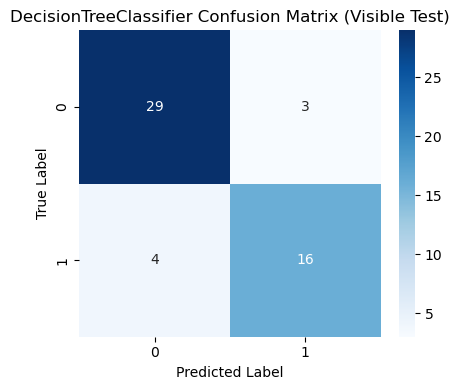

Visible Test GradientBoostingClassifier Results
-----------------------------------------------
Accuracy : 0.8462
Precision: 0.8750
Recall   : 0.7000
F1-score : 0.7778


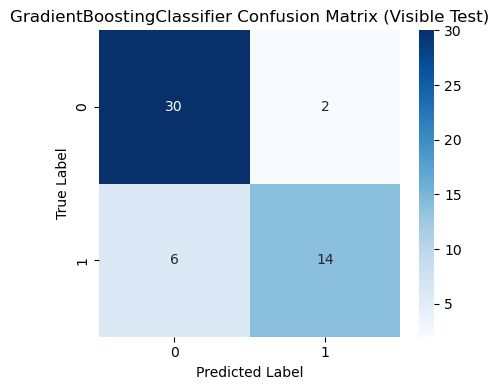

Visible Test SVC Results
------------------------
Accuracy : 0.8077
Precision: 0.7083
Recall   : 0.8500
F1-score : 0.7727


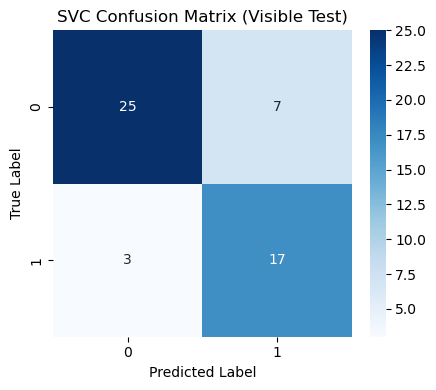

In [18]:
train_dataset = Dataset(PATH_TO_TRAIN_FILE, do_fit=True)
test_dataset = Dataset(PATH_TO_STUDENT_TEST_FILE, preprocessor=train_dataset.preprocessor, do_fit=False)
hidden_dataset = Dataset(PATH_TO_HIDDEN_TEST_SAMPLE_FILE, preprocessor=train_dataset.preprocessor, do_fit=False)

dt_trainer = ModelTrainer(get_decision_tree_classifier())
dt_trainer.train(train_dataset)
dt_trainer.evaluate(test_dataset, title_prefix="Visible Test")
dt_predictions = dt_trainer.predict(hidden_dataset)

gb_trainer = ModelTrainer(get_boosting_classifier())
gb_trainer.train(train_dataset)
gb_trainer.evaluate(test_dataset, title_prefix="Visible Test")
gb_predictions = gb_trainer.predict(hidden_dataset)

svm_trainer = ModelTrainer(get_svm_classifier())
svm_trainer.train(train_dataset)
svm_trainer.evaluate(test_dataset, title_prefix="Visible Test")
svm_predictions = svm_trainer.predict(hidden_dataset)